
# Classificação de Reservas de Hotel por Faixa de Preço

**Tipo de Problema:** Classificação Multiclasse Supervisionada  

Este notebook documenta a etapa de **treinamento, avaliação e refinamento de modelos de Machine Learning**, com foco na classificação de reservas de hotel em faixas de preço.

---

## 1. Definição do Problema

O objetivo deste projeto é desenvolver um modelo de **Aprendizado de Máquina supervisionado** capaz de classificar reservas de hotel em **faixas de preço**, utilizando características da reserva e do comportamento do consumidor.

### Estratégias Avaliadas
- **Abordagem Inicial:** Classificação em 4 classes  
  *(Econômica, Padrão, Premium e Luxo)*  
- **Abordagem Final:** Reestruturação para 3 classes  
  *(Econômica, Standard e Luxo)*  

A redefinição do problema foi motivada por **evidências experimentais de sobreposição estatística** entre as classes intermediárias.

---


## 2. Configuração do Ambiente

Nesta seção são importadas as bibliotecas utilizadas ao longo do experimento, abrangendo:
- Manipulação e análise de dados
- Visualização gráfica
- Treinamento e avaliação de modelos de Machine Learning

O principal framework utilizado foi o **scikit-learn**, complementado por bibliotecas especializadas como **XGBoost**.


In [36]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier



## 3. Carregamento dos Dados

O dataset utilizado corresponde à versão **pré-processada** dos dados de reservas de hotel,
contendo informações históricas relacionadas ao perfil da reserva, antecedência de compra
e características da hospedagem.


In [37]:

df = pd.read_csv("./data/processed/hotel_bookings_processed.csv")
df.head()


,adults,children,stays_in_weekend_nights,stays_in_week_nights,meal,required_car_parking_spaces,reserved_room_type,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,market_segment,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,adr,total_of_special_requests,reservation_status,faixa_preco
0,1,0.0,0,1,BB,0,A,7,2015,July,1,Direct,0,0,0,75.0,0,Check-Out,Padrão
1,1,0.0,0,1,BB,0,A,13,2015,July,1,Corporate,0,0,0,75.0,0,Check-Out,Padrão
2,2,0.0,0,2,BB,0,A,14,2015,July,1,Online TA,0,0,0,98.0,1,Check-Out,Padrão
3,2,0.0,0,2,BB,0,C,0,2015,July,1,Direct,0,0,0,107.0,0,Check-Out,Premium
4,2,0.0,0,2,FB,0,C,9,2015,July,1,Direct,0,0,0,103.0,1,Check-Out,Premium



## 4. Pré-processamento e Prevenção de Data Leakage

Nesta etapa são realizadas transformações fundamentais para garantir a **validade estatística do experimento**.

### Decisões Tomadas
- Definição da variável alvo (faixa de preço)
- Remoção de variáveis que representam a resposta ou informações do futuro
- Codificação de variáveis categóricas via One-Hot Encoding


In [38]:

# 1. Definição do alvo
y = df['faixa_preco']

# 2. Remoção de colunas com leakage ou ruído
colunas_para_remover = [
    'faixa_preco',              # É o alvo
    'adr',                      # LEAKAGE GRAVE (é a resposta)
    'reservation_status',       # Dado do futuro
    'arrival_date_year',        # Viés temporal
    'arrival_date_day_of_month' # Ruído
]

X = df.drop(columns=colunas_para_remover)

# 3. One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=['meal', 'market_segment', 'reserved_room_type', 'arrival_date_month'],
    drop_first=True
)

print(f"Total de variáveis após encoding: {X.shape[1]}")
print(X.head())

Total de variáveis após encoding: 40
   adults  children  stays_in_weekend_nights  stays_in_week_nights  \
0       1       0.0                        0                     1   
1       1       0.0                        0                     1   
2       2       0.0                        0                     2   
3       2       0.0                        0                     2   
4       2       0.0                        0                     2   

   required_car_parking_spaces  lead_time  is_repeated_guest  \
0                            0          7                  0   
1                            0         13                  0   
2                            0         14                  0   
3                            0          0                  0   
4                            0          9                  0   

   previous_cancellations  previous_bookings_not_canceled  \
0                       0                               0   
1                       0          


## 5. Divisão dos Dados – Planejamento Experimental

Os dados foram divididos em conjuntos de treino (80%) e teste (20%) utilizando a técnica de **holdout**,
permitindo avaliar a capacidade de generalização do modelo.


In [39]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 6. Modelo Baseline – Árvore de Decisão

Como ponto de partida, foi treinado um modelo simples de **Árvore de Decisão**, que serviu como baseline para comparação de desempenho.

Modelos baseline são importantes para avaliar se abordagens mais complexas realmente agregam valor ao problema.


In [40]:
#  Criação do Modelo
# max_depth=5 limita a profundidade para a árvore não decorar os dados (Overfitting)
modelo = DecisionTreeClassifier(max_depth=12, random_state=42)

modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
# print(classification_report(y_test, y_pred))

# Avaliação
print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred))


Relatório de Classificação:

              precision    recall  f1-score   support

   Econômica       0.61      0.68      0.64      3969
        Luxo       0.64      0.70      0.67      3633
      Padrão       0.52      0.33      0.40      3884
     Premium       0.48      0.55      0.52      4132

    accuracy                           0.57     15618
   macro avg       0.56      0.57      0.56     15618
weighted avg       0.56      0.57      0.56     15618




## 7. Random Forest

O algoritmo **Random Forest** foi utilizado como modelo base por sua capacidade de generalização
e robustez frente a dados não lineares.


In [41]:

modelo = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

   Econômica       0.65      0.73      0.69      3969
        Luxo       0.73      0.71      0.72      3633
      Padrão       0.61      0.40      0.48      3884
     Premium       0.52      0.64      0.57      4132

    accuracy                           0.62     15618
   macro avg       0.63      0.62      0.61     15618
weighted avg       0.62      0.62      0.61     15618




### Análise de Importância das Variáveis

Esta análise permite compreender quais atributos mais influenciam a decisão do modelo,
garantindo interpretabilidade e coerência com o domínio do problema.


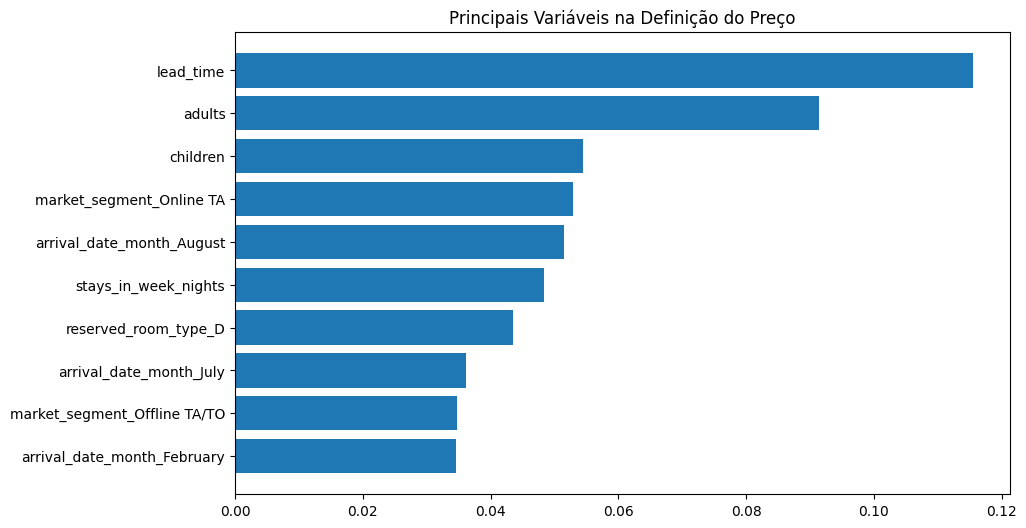

In [42]:

importancias = modelo.feature_importances_
df_importancia = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importancias
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(df_importancia['Feature'][:10], df_importancia['Importance'][:10])
plt.gca().invert_yaxis()
plt.title('Principais Variáveis na Definição do Preço')
plt.show()



## 8. Otimização de Hiperparâmetros

Aplicação de GridSearchCV para identificar a melhor combinação de hiperparâmetros,
equilibrando desempenho e complexidade do modelo.


In [43]:

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=modelo,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Melhores parâmetros:", grid_search.best_params_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Melhores parâmetros: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}



## 9. Refinamento do Modelo e Análise de Erros

Avaliação do modelo otimizado utilizando engenharia de atributos adicional
e análise da matriz de confusão.


In [44]:
# 1. Pequena Engenharia de Features (Baseada no seu gráfico)
# Vamos ajudar o modelo somando as pessoas, já que ambas as colunas são importantes
X_train['total_pessoas'] = X_train['adults'] + X_train['children']
X_test['total_pessoas'] = X_test['adults'] + X_test['children']

# 2. Configurando o Modelo com os "Melhores Parâmetros"
modelo_final = RandomForestClassifier(
    n_estimators=200,       # Aumentamos o número de árvores
    max_depth=20,           # Demos mais profundidade
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

modelo_final.fit(X_train, y_train)
y_pred_final = modelo_final.predict(X_test)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

   Econômica       0.69      0.73      0.71      3969
        Luxo       0.73      0.72      0.73      3633
      Padrão       0.62      0.48      0.54      3884
     Premium       0.55      0.65      0.60      4132

    accuracy                           0.65     15618
   macro avg       0.65      0.65      0.65     15618
weighted avg       0.65      0.65      0.64     15618



### Matriz de Confusão

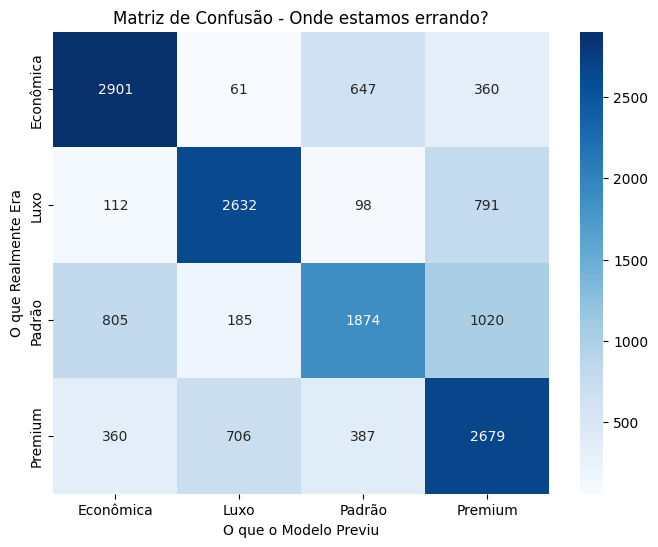

In [45]:
# Gerar a matriz
cm = confusion_matrix(y_test, y_pred_final)

# Plotar
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=modelo_final.classes_, 
            yticklabels=modelo_final.classes_)
plt.xlabel('O que o Modelo Previu')
plt.ylabel('O que Realmente Era')
plt.title('Matriz de Confusão - Onde estamos errando?')
plt.show()


## 10. Testes com Modelos Avançados (XGBoost e Voting Classifier)

Foram avaliados modelos mais complexos para verificar possíveis ganhos adicionais.
Os resultados indicaram um limite estrutural dos dados.


In [46]:
###Teste com XBoosting

# O XGBoost exige que as classes sejam números de 0 a 3 (não strings)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Configuração poderosa
modelo_xgb = XGBClassifier(
    n_estimators=500,       # Mais árvores, pois elas são pequenas
    learning_rate=0.05,     # Aprende devagar para não decorar (Overfitting)
    max_depth=6,            # Profundidade média
    subsample=0.8,          # Usa 80% dos dados por árvore para variar
    colsample_bytree=0.8,   # Usa 80% das colunas por árvore
    random_state=42,
    n_jobs=-1
)

modelo_xgb.fit(X_train, y_train_encoded)

# Previsão
y_pred_xgb = modelo_xgb.predict(X_test)
# Converter de volta para nomes (0 -> Econômica) para o relatório
y_pred_decodificado = le.inverse_transform(y_pred_xgb)

print(classification_report(y_test, y_pred_decodificado))

              precision    recall  f1-score   support

   Econômica       0.68      0.72      0.70      3969
        Luxo       0.72      0.73      0.73      3633
      Padrão       0.59      0.45      0.51      3884
     Premium       0.54      0.62      0.58      4132

    accuracy                           0.63     15618
   macro avg       0.63      0.63      0.63     15618
weighted avg       0.63      0.63      0.63     15618



### Criando o modelo Voting Classifier

In [47]:
# 1. Recriar os modelos com as melhores configurações que achamos até agora
rf_best = RandomForestClassifier(
    n_estimators=200, 
    max_depth=20, 
    min_samples_split=2, 
    random_state=42, 
    n_jobs=-1
)

xgb_best = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,          
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# 2. Criar o "Super Modelo" de Votação
# voting='soft' usa as probabilidades. voting='hard' usa apenas o voto final (vence a maioria).
# Soft geralmente funciona melhor.
modelo_voto = VotingClassifier(
    estimators=[('rf', rf_best), ('xgb', xgb_best)],
    voting='soft'
)

# 3. Treinar o conjunto
# Nota: Precisamos usar o y_train_encoded (numérico) por causa do XGBoost
modelo_voto.fit(X_train, y_train_encoded)

# 4. Avaliar
y_pred_voto = modelo_voto.predict(X_test)
y_pred_decodificado = le.inverse_transform(y_pred_voto)

print("=== Relatório do Voting Classifier ===")
print(classification_report(y_test, y_pred_decodificado))

=== Relatório do Voting Classifier ===
              precision    recall  f1-score   support

   Econômica       0.71      0.73      0.72      3969
        Luxo       0.74      0.74      0.74      3633
      Padrão       0.63      0.52      0.57      3884
     Premium       0.57      0.65      0.61      4132

    accuracy                           0.66     15618
   macro avg       0.66      0.66      0.66     15618
weighted avg       0.66      0.66      0.66     15618




## 11. Redefinição do Problema – Classificação com 3 Classes

Devido à sobreposição estatística entre as classes intermediárias,
optou-se pela fusão em uma classe única denominada **Standard**.


In [48]:
### Reduzindo o número de classes alvo

# 1. Criar uma cópia da coluna alvo original para não perder os dados
y_tres_classes = y.copy()

# 2. Substituir os valores (Fundindo Padrão e Premium)
mapa_fusao = {
    'Econômica': 'Econômica',
    'Padrão': 'Standard',
    'Premium': 'Standard',
    'Luxo': 'Luxo'
}

y_tres_classes = y_tres_classes.map(mapa_fusao)

# 3. Verificar se funcionou (deve ter apenas 3 barras agora)
print(y_tres_classes.value_counts())

faixa_preco
Standard     40254
Econômica    19640
Luxo         18194
Name: count, dtype: int64


In [49]:
# Nova divisão (usando o y_tres_classes)
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X, y_tres_classes, test_size=0.2, random_state=42
)

# Configurar o modelo (usando os hiperparâmetros que já sabemos que são bons)
modelo_final_3c = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

modelo_final_3c.fit(X_train_3, y_train_3)
y_pred_3 = modelo_final_3c.predict(X_test_3)

print("=== Relatório com 3 Classes ===")
print(classification_report(y_test_3, y_pred_3))

=== Relatório com 3 Classes ===
              precision    recall  f1-score   support

   Econômica       0.77      0.61      0.68      3969
        Luxo       0.81      0.65      0.72      3633
    Standard       0.71      0.85      0.78      8016

    accuracy                           0.74     15618
   macro avg       0.76      0.70      0.73     15618
weighted avg       0.75      0.74      0.74     15618




## 12. Modelo Final Balanceado

Aplicação de `class_weight='balanced'` para mitigar viés da classe majoritária
e maximizar o Recall das classes minoritárias.


In [50]:
### Aplicando balanceamento automático

modelo_final_balanceado = RandomForestClassifier(
    n_estimators=300,       
    max_depth=20,
    min_samples_split=2,
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

modelo_final_balanceado.fit(X_train_3, y_train_3)

y_pred_bal = modelo_final_balanceado.predict(X_test_3)

print("=== Tentativa Final: 3 Classes Balanceadas ===")
print(classification_report(y_test_3, y_pred_bal))

=== Tentativa Final: 3 Classes Balanceadas ===
              precision    recall  f1-score   support

   Econômica       0.65      0.78      0.71      3969
        Luxo       0.68      0.78      0.73      3633
    Standard       0.78      0.65      0.71      8016

    accuracy                           0.72     15618
   macro avg       0.70      0.74      0.72     15618
weighted avg       0.72      0.72      0.71     15618

